In [1]:
# ================= PORT NA KONWENCJE ARTYKULU (06.09.2026) =================
# Ten notebook jest PORTEM 20260904a.ipynb. Analiza, generatory surogatow, reguly
# odczytu i wykresy sa NIETKNIETE - zmienila sie WYLACZNIE konwencja
# binowania (komorka ze statystyka liczy teraz przez ../statystyka.py w
# konwencji kodu zespolu) oraz nazwy plikow: wejsciowe finetune_* -> credo_*,
# wyjsciowe dostaly przedrostek credo_, zeby nic ze starych wynikow nie
# zostalo nadpisane. Powod i walidacja: dziennik 20260905.txt pkt 13a-13g
# oraz 20260906a.ipynb.
# ==========================================================================

# 04.09.2026 - 20260904a.ipynb: KRZYWE W STYLU FIG. 4 DLA PELNEGO PLANU 2x2.
#
# JEDEN watek (konwencja repo: jeden watek = jeden notebook).
#
# PO CO. 20260903c zmierzyl plan 2x2 (cztery wersje katalogu x 50 realizacji) i
# podal liczby minimow na realizacje - 4,90 / 4,88 / 0,80 / 0,08 - ale ZAPISAL
# TYLKO TABELE MINIMOW (results/credo_czynniki_minima_mosc.csv). Same krzywe poszly do
# kosza. 20260903d narysowal krzywe w stylu Fig. 4, ale dla innego zestawu
# paneli: dwa z nich sa diagnostyczne (kontrola z 02.09 i jej odtworzenie), a
# komorki planu "tempo prawdziwe + magnitudy z calego katalogu" tam nie ma.
#
# Nie istnieje wiec rysunek pokazujacy krzywa -log10(PPDF) dla WSZYSTKICH
# CZTERECH kombinacji przelacznikow. Ten notebook go robi. Jest to uzupelnienie
# materialu rysunkowego - zadna liczba z 20260903c sie nie zmienia.
#
# CO SIE PRZELACZA (definicje z 20260903c, bez zmian):
#   przelacznik I - TEMPO, czyli liczba zdarzen na rok:
#       "praw"     - roczne liczby zdarzen dokladnie jak w katalogu USGS
#                    (stosunek dekad 2005-2014 / 1970-1979 = 4,36),
#       "plaskie"  - te same laczne zdarzenia rozlozone rowno na lata
#                    (stosunek dekad = 1,00).
#   przelacznik II - SKLAD MAGNITUD:
#       "mag_rok"  - magnitudy losowane ze zwracaniem z puli TEGO SAMEGO roku
#                    (historyczny dryf skladu zostaje),
#       "mag_glob" - magnitudy losowane ze zwracaniem z puli CALEGO katalogu
#                    (dryf skladu wymazany).
# We wszystkich czterech wersjach identyczne sa: laczna liczba zdarzen co do
# jednego (507 919), losowanie czasow jednostajnie w obrebie roku (czyli
# zniszczenie CALEJ struktury ponizej roku - w tym efektu prekursorowego przy
# dt = 15 dni przyjetym w artykule), poprawka na niepelny rok 2025, statystyka,
# siatka t0 i prog detekcji.
#
# DWIE DECYZJE, KTORE ODROZNIAJA TEN NOTEBOOK OD PIERWSZEJ WERSJI Z DZIS
# (obie sa reakcja na wady tamtej, opisane w dzienniku 20260904.txt):
#
#  (1) ZERO PODPROBKOWANIA. Pierwsza wersja zapisywala krzywe co czwarty punkt,
#      bo odziedziczyla stala PODPROBKA po 20260903d. Tam mialo to twardy powod:
#      trzeba bylo zlozyc krzywe punkt w punkt z plikiem z 02.09, zapisanym
#      wlasnie tak. Tutaj tego powodu nie ma - z niczym tamtym nie porownujemy.
#      Podprobkowanie wymuszalo za to osobna kontrole "czy nie gubimy szczytow",
#      ktora okazala sie krucha. Zapisujemy wiec pelna siatke 6 h i ta kontrola
#      znika razem z powodem swojego istnienia.
#
#  (2) ZIARNA DOBRANE TAK, ZEBY NASZE REALIZACJE BYLY PODZBIOREM TYCH Z
#      20260903c. Tamten notebook nadawal ziarna jako ZIARNO_BAZOWE + 1000*i + j,
#      gdzie i to indeks wersji na liscie WERSJE. Powtarzamy ten sam przepis dla
#      j = 0..9, wiec kazda nasza krzywa ma swoj odpowiednik wsrod tamtych 50.
#      Dzieki temu kontrola w komorce 4 jest testem ZDAL/OBLAL na dokladna
#      zgodnosc liczby minimow, a nie regula z tolerancja statystyczna.
#
# KOSZT [szacunek]: 40 krzywych po 74 322 punkty t0. W 20260903c 201 krzywych
# poszlo w 11,8 min na 20 rdzeniach (3,5 s na krzywa), wiec tu okolo 2,4 min.
# Plik wynikowy urosnie do ok. 60 MB - results/*.csv nie idzie do gita.
import json
import os
import sys
import time

import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from scipy.stats import binom

sys.path.insert(0, "..")
from mc_parallel import run_jobs_parallel

RESULTS_DIR = "../results"
DATA_DIR = "../data"
USGS_PATH = f"{DATA_DIR}/usgs_data/usgs_m4_1965_2025.csv"
MOSC_PATH = f"{DATA_DIR}/mosc_data.csv"

P_DAYS, D_DAYS, M_THRESHOLD, DT_DAYS = 3350, 5, 4.0, 15
PROG_WYSOKOSCI = 5.0
STACJA = "mosc"
N_POKAZ = 10             # realizacji na wersje NA RYSUNKU (w 20260903c bylo 50)

# KOLEJNOSC MA ZNACZENIE: musi byc identyczna jak lista WERSJE w 20260903c,
# bo z indeksu na tej liscie liczone jest ziarno. Sprawdzane asercja nizej.
WERSJE = ["tempo_praw__mag_rok", "tempo_praw__mag_glob",
          "tempo_plaskie__mag_rok", "tempo_plaskie__mag_glob"]
ZIARNO_BAZOWE = 20260903
ZIARNA = {w: [ZIARNO_BAZOWE + 1000 * i + j for j in range(N_POKAZ)]
          for i, w in enumerate(WERSJE)}

_konf_c = json.load(open(f"{RESULTS_DIR}/credo_czynniki_config_{STACJA}.json"))
assert _konf_c["WERSJE"] == WERSJE, (
    f"Kolejnosc wersji rozni sie od 20260903c ({_konf_c['WERSJE']}) - ziarna "
    f"wyjda inne i kontrola w komorce 4 nie ma prawa przejsc.")
assert _konf_c["ZIARNO_BAZOWE"] == ZIARNO_BAZOWE
for _k in ("P_DAYS", "D_DAYS", "DT_DAYS", "M_THRESHOLD", "PROG_WYSOKOSCI"):
    assert _konf_c[_k] == globals()[_k], f"{_k} rozni sie od 20260903c"
print(f"Konfiguracja zgodna z 20260903c (results/credo_czynniki_config_{STACJA}.json).")

katalog = pd.read_csv(USGS_PATH, usecols=["time", "mag"])
katalog["time"] = pd.to_datetime(katalog["time"], utc=True).dt.tz_localize(None)
katalog = katalog[katalog["mag"] >= M_THRESHOLD].sort_values("time").reset_index(drop=True)

cr = pd.read_csv(MOSC_PATH)
cr["datetime"] = pd.to_datetime(cr["datetime"])
cr = cr.set_index("datetime").sort_index()["value"]

print(f"Katalog USGS M>={M_THRESHOLD}: {len(katalog)} zdarzen, "
      f"{katalog['time'].min().date()} .. {katalog['time'].max().date()}")
print(f"CR {STACJA}: {len(cr)} pomiarow")
for w in WERSJE:
    print(f"  {w:<26s} ziarna {ZIARNA[w][0]}..{ZIARNA[w][-1]}")


Konfiguracja zgodna z 20260903c (results/credo_czynniki_config_mosc.json).
Katalog USGS M>=4.0: 507919 zdarzen, 1965-01-01 .. 2025-01-31
CR mosc: 91824 pomiarow
  tempo_praw__mag_rok        ziarna 20260903..20260912
  tempo_praw__mag_glob       ziarna 20261903..20261912
  tempo_plaskie__mag_rok     ziarna 20262903..20262912
  tempo_plaskie__mag_glob    ziarna 20263903..20263912


In [2]:
# STATYSTYKA - w tym miejscu byla kopia funkcji, ta sama co w osmiu innych
# notebookach. Od 06.09 caly repo liczy przez wspolny modul ../statystyka.py,
# w KONWENCJI ARTYKULU: okno o jeden kosz przed t0, krata zakotwiczona w
# pierwszym dostepnym rekordzie (efektywne dt ok. 14,8 dnia zamiast 15),
# mediany po filtrze, filtr skrocony, remisy w mianowniku. Uzasadnienie:
# 20260905c.ipynb i dziennik 20260905.txt pkt 13a-13g; walidacja modulu
# (odtworzenie tabeli koszy zespolu kosz w kosz): 20260906a.ipynb.
#
# Nazwy przygotuj_szereg / przygotuj_katalog / y_krzywa zostaja te same, zeby
# reszta notebooka byla NIETKNIETA - to jest port konwencji, a nie nowa analiza.
sys.path.insert(0, "..")
import importlib

import statystyka as st
importlib.reload(st)   # statystyka.py jest w trakcie rozwoju; bez reload jadro
                       # trzyma wersje z pierwszego importu i zmiany na dysku sa
                       # niewidoczne az do restartu kernela

KONWENCJA = st.CREDO
OKNO = st.okno(P_DAYS, D_DAYS, DT_DAYS, KONWENCJA)
przygotuj_szereg = st.przygotuj_szereg
przygotuj_katalog = st.przygotuj_katalog


# MAX_JITTER_D - higiena skanu, nie zmiana statystyki. Kotwiczenie na danych
# (konwencja zespolu) przy skanie po calej historii cicho przenosi okno przez
# dziury w szeregu CR: liczylibysmy wtedy okno przesuniete o dlugosc dziury, a
# wynik wygladalby na policzony. Punkty, w ktorych efektywne dt odbiega od
# nominalnego o wiecej niz szerokosc kosza, dostaja NaN - tak samo jak punkty
# bez danych w starej konwencji. Uzasadnienie: docstring statystyka.krzywa i
# dziennik 20260906.txt sekcja 9.
MAX_JITTER_D = D_DAYS


def y_krzywa(cr_prep, eq_prep, siatka_ns):
    return st.krzywa(cr_prep, eq_prep, siatka_ns, OKNO, max_jitter_d=MAX_JITTER_D)[0]


print(f"Konwencja: {KONWENCJA}")
print(f"Okno: P = {P_DAYS} d, d = {D_DAYS} d, dt = {DT_DAYS} d -> "
      f"{OKNO.n_koszy} koszy, {OKNO.n_koszy - 1} par "
      f"(stara konwencja miala {int(P_DAYS // D_DAYS)} koszy, "
      f"{int(P_DAYS // D_DAYS) - 1} par)")


ft = (pd.read_csv(f"{RESULTS_DIR}/credo_{STACJA}_P3350_d5_dt15_fullhistory.csv",
                  parse_dates=["t0"]).sort_values("t0").reset_index(drop=True))
siatka = ft["t0"]
siatka_ns = siatka.values.astype("datetime64[ns]").astype(np.int64)
cr_prep = przygotuj_szereg(cr)
KROK_DNI = (siatka.iloc[1] - siatka.iloc[0]) / pd.Timedelta(days=1)
DISTANCE = int(round(P_DAYS / KROK_DNI))
assert len(siatka) == _konf_c["n_siatka"], "Siatka t0 rozni sie od 20260903c"

# KONTROLA (ta sama co w 20260903b/c/d): czy nasza krzywa dla katalogu
# prawdziwego to ta sama krzywa, co zapisana 26.08. Jesli nie - nic dalej nie
# ma sensu i notebooka nie wolno czytac.
y_prawdziwa = y_krzywa(cr_prep, przygotuj_katalog(katalog), siatka_ns)
_ref = -np.log10(ft["PPDF"].to_numpy())
_d = np.abs(y_prawdziwa - _ref)
_ok = ~np.isnan(_d)
print(f"Kontrola wzgledem krzywej z 26.08: korelacja "
      f"{np.corrcoef(y_prawdziwa[_ok], _ref[_ok])[0, 1]:.6f}, "
      f"punktow z |roznica| > 0,2: {int(np.nansum(_d > 0.2))} / {len(_d)}")
print(f"Siatka t0: {len(siatka)} punktow, krok {KROK_DNI * 24:.0f} h, "
      f"{siatka.iloc[0].date()} .. {siatka.iloc[-1].date()}")
print(f"find_peaks: prog {PROG_WYSOKOSCI}, distance {DISTANCE} probek "
      f"(= {P_DAYS} dni = {P_DAYS / 365.25:.2f} roku)")

_piki_praw, _ = find_peaks(np.nan_to_num(y_prawdziwa, nan=-1.0),
                           height=PROG_WYSOKOSCI, distance=DISTANCE)
daty_praw = [siatka.iloc[p] for p in _piki_praw]
print("Ery katalogu prawdziwego: "
      + ", ".join(f"{d.date()} ({y_prawdziwa[p]:.2f})" for d, p in zip(daty_praw, _piki_praw)))


Konwencja: Konwencja(kotwica='dane', wiodacy_kosz=True, mediany='po_filtrze', filtr='skrocony', remisy='w_N')
Okno: P = 3350 d, d = 5 d, dt = 15 d -> 671 koszy, 670 par (stara konwencja miala 670 koszy, 669 par)
Kontrola wzgledem krzywej z 26.08: korelacja 1.000000, punktow z |roznica| > 0,2: 0 / 74322
Siatka t0: 74322 punktow, krok 6 h, 1965-01-01 .. 2015-11-15
find_peaks: prog 5.0, distance 13400 probek (= 3350 dni = 9.17 roku)
Ery katalogu prawdziwego: 1968-03-24 (9.72), 1978-05-24 (6.20), 1989-03-03 (6.68), 1999-02-18 (7.84), 2008-08-08 (8.46)


In [3]:
# GENERATOR 2x2 - przepisany bez zmian z 20260903c/d. Kluczowa jest KOLEJNOSC
# wywolan rng wewnatrz petli po latach (najpierw czasy, potem magnitudy): to ona
# zapewnia, ze przy tym samym ziarnie dostajemy ten sam katalog co tam.
_KAT_OD, _KAT_DO = katalog["time"].min(), katalog["time"].max()
_grupy = {int(r): g["mag"].to_numpy() for r, g in katalog.groupby(katalog["time"].dt.year)}
LATA = np.array(sorted(_grupy))
LICZBY = np.array([len(_grupy[int(r)]) for r in LATA], dtype=float)
GRANICE = {}
for r in LATA:
    od = max(pd.Timestamp(year=int(r), month=1, day=1), _KAT_OD)
    do = min(pd.Timestamp(year=int(r) + 1, month=1, day=1), _KAT_DO)
    GRANICE[int(r)] = (od, (do - od).total_seconds())
DLUGOSC_ROKU = np.array([(pd.Timestamp(year=int(r) + 1, month=1, day=1)
                          - pd.Timestamp(year=int(r), month=1, day=1)).total_seconds()
                         for r in LATA])
POKRYCIE = np.array([GRANICE[int(r)][1] for r in LATA]) / DLUGOSC_ROKU
_WSZYSTKIE_MAG = katalog["mag"].to_numpy()


def do_liczb(tempo_profilu):
    """Profil tempa (zdarzen na PELNY rok) -> calkowite liczby zdarzen na rok,
    o sumie DOKLADNIE rownej liczbie zdarzen w prawdziwym katalogu."""
    surowe = np.asarray(tempo_profilu, dtype=float) * POKRYCIE
    surowe = surowe / surowe.sum() * LICZBY.sum()
    dol = np.floor(surowe).astype(int)
    brak = int(round(LICZBY.sum() - dol.sum()))
    if brak > 0:
        dol[np.argsort(-(surowe - dol))[:brak]] += 1
    return dol


TEMPO_PRAW = LICZBY / POKRYCIE
LICZBY_WERSJI = {"praw": do_liczb(TEMPO_PRAW),
                 "plaskie": do_liczb(np.full(len(LATA), TEMPO_PRAW.mean()))}


def zbuduj(wersja, ziarno):
    tempo, magi = wersja.split("__")
    liczby = LICZBY_WERSJI[tempo.replace("tempo_", "")]
    rng = np.random.default_rng(ziarno)
    czesci = []
    for i, rok in enumerate(LATA):
        n = int(liczby[i])
        if n == 0:
            continue
        poczatek, dlugosc = GRANICE[int(rok)]
        pula = _grupy[int(rok)] if magi == "mag_rok" else _WSZYSTKIE_MAG
        czesci.append(pd.DataFrame(dict(
            time=poczatek + pd.to_timedelta(rng.uniform(0, dlugosc, n), unit="s"),
            mag=rng.choice(pula, size=n, replace=True))))
    s = pd.concat(czesci, ignore_index=True).sort_values("time").reset_index(drop=True)
    s["time"] = s["time"].dt.floor("s").astype("datetime64[us]")
    return s


# KONTROLA GENERATORA: czy przelaczniki przelaczaja to, co maja. Kolumna "n"
# mowi, czy splaszczylismy TEMPO; kolumna "Sm" - czy splaszczylismy to, co
# statystyka naprawde czyta. Powtorzenie wydruku z 20260903c.
def _stosunek_dekad(df, kolumna):
    lata = df["time"].dt.year
    pozno = df.loc[(lata >= 2005) & (lata <= 2014), "mag"]
    wcz = df.loc[(lata >= 1970) & (lata <= 1979), "mag"]
    return (len(pozno) / len(wcz)) if kolumna == "n" else (pozno.sum() / wcz.sum())


print(f"{'wersja':<26s} {'zdarzen':>9s} {'n 05-14/70-79':>15s} "
      f"{'Sm 05-14/70-79':>16s} {'sr.mag 70-79':>14s} {'sr.mag 05-14':>14s}")
_lp = katalog["time"].dt.year
print(f"{'prawdziwy':<26s} {len(katalog):>9d} "
      f"{_stosunek_dekad(katalog, 'n'):>15.2f} {_stosunek_dekad(katalog, 'Sm'):>16.2f} "
      f"{katalog.loc[(_lp >= 1970) & (_lp <= 1979), 'mag'].mean():>14.4f} "
      f"{katalog.loc[(_lp >= 2005) & (_lp <= 2014), 'mag'].mean():>14.4f}")
for w in WERSJE:
    _s = zbuduj(w, ZIARNA[w][0])
    _l = _s["time"].dt.year
    print(f"{w:<26s} {len(_s):>9d} "
          f"{_stosunek_dekad(_s, 'n'):>15.2f} {_stosunek_dekad(_s, 'Sm'):>16.2f} "
          f"{_s.loc[(_l >= 1970) & (_l <= 1979), 'mag'].mean():>14.4f} "
          f"{_s.loc[(_l >= 2005) & (_l <= 2014), 'mag'].mean():>14.4f}")
del _s, _l


wersja                       zdarzen   n 05-14/70-79   Sm 05-14/70-79   sr.mag 70-79   sr.mag 05-14
prawdziwy                     507919            4.36             4.05         4.9037         4.5495
tempo_praw__mag_rok           507919            4.36             4.05         4.9031         4.5488
tempo_praw__mag_glob          507919            4.36             4.37         4.5967         4.6008
tempo_plaskie__mag_rok        507919            1.00             0.90         5.0572         4.5557
tempo_plaskie__mag_glob       507919            1.00             1.00         4.5995         4.6008


In [4]:
# RACHUNEK. Czterdziesci krzywych (4 wersje x 10 realizacji) po PELNEJ siatce
# 74 322 punktow, zapisywanych BEZ podprobkowania. Nic nie jest wczytywane z
# poprzednich plikow - to jest swiadoma decyzja, opisana w komorce 0.
SCIEZKA = f"{RESULTS_DIR}/credo_czynniki_fig4_krzywe_{STACJA}.csv"
SCIEZKA_KONFIG = f"{RESULTS_DIR}/credo_czynniki_fig4_config_{STACJA}.json"
PRZELICZ_OD_NOWA = False

ZADANIA = [(w, z) for w in WERSJE for z in ZIARNA[w]]


def konfiguracja():
    return dict(STACJA=STACJA, P_DAYS=P_DAYS, D_DAYS=D_DAYS, DT_DAYS=DT_DAYS,
                M_THRESHOLD=M_THRESHOLD, PROG_WYSOKOSCI=PROG_WYSOKOSCI,
                PODPROBKA=1, N_POKAZ=N_POKAZ, ZIARNO_BAZOWE=ZIARNO_BAZOWE,
                WERSJE=WERSJE, ZIARNA={w: ZIARNA[w] for w in WERSJE},
                katalog_n=int(len(katalog)), n_siatka=int(len(siatka)))


def zadanie(job):
    typ, ziarno = job
    y = y_krzywa(cr_prep, przygotuj_katalog(zbuduj(typ, ziarno)), siatka_ns)
    return dict(kolumna=f"{typ}__{ziarno}", krzywa=[float(v) for v in y])


wczytano = False
if not PRZELICZ_OD_NOWA and os.path.exists(SCIEZKA) and os.path.exists(SCIEZKA_KONFIG):
    if json.load(open(SCIEZKA_KONFIG)) == json.loads(json.dumps(konfiguracja())):
        krzywe = pd.read_csv(SCIEZKA, parse_dates=["srodek_okna"])
        wczytano = True
        print(f"WCZYTANO {SCIEZKA} - nic nie liczono.")
    else:
        print("Zapisana konfiguracja nie pasuje - liczymy od nowa.")

if not wczytano:
    print(f"Liczymy {len(ZADANIA)} krzywych x {len(siatka)} punktow t0.")
    start = time.time()
    surowe = run_jobs_parallel(zadanie, ZADANIA, opis="krzywych", raport_co=5)
    print(f"Czas calkowity: {(time.time() - start) / 60:.1f} min")
    kolumny = {"srodek_okna": siatka.reset_index(drop=True) + pd.Timedelta(days=P_DAYS / 2),
               "prawdziwy__0": y_prawdziwa}
    for r in surowe.itertuples():
        kolumny[r.kolumna] = r.krzywa
    krzywe = pd.DataFrame(kolumny)
    krzywe.to_csv(SCIEZKA, index=False)
    json.dump(konfiguracja(), open(SCIEZKA_KONFIG, "w"), indent=1)
    print(f"Zapisano {SCIEZKA} ({os.path.getsize(SCIEZKA) / 1e6:.0f} MB)")

KOL = {w: [f"{w}__{z}" for z in ZIARNA[w]] for w in WERSJE}
_brak = [k for w in WERSJE for k in KOL[w] if k not in krzywe.columns]
assert not _brak, f"Brakuje kolumn: {_brak[:5]}"
assert len(krzywe) == len(siatka), (
    f"Krzywe maja {len(krzywe)} punktow zamiast {len(siatka)} - podprobkowanie "
    f"nie powinno tu wystapic.")
print(f"Krzywe: {len(krzywe)} punktow (pelna siatka, krok {KROK_DNI * 24:.0f} h), "
      f"{len(krzywe.columns) - 1} kolumn.")


Liczymy 40 krzywych x 74322 punktow t0.
  5/40 krzywych; minelo 1.3 min, zostalo ~9.4 min
  10/40 krzywych; minelo 1.4 min, zostalo ~4.2 min
  15/40 krzywych; minelo 1.4 min, zostalo ~2.4 min
  20/40 krzywych; minelo 1.5 min, zostalo ~1.5 min
  25/40 krzywych; minelo 2.4 min, zostalo ~1.4 min
  30/40 krzywych; minelo 2.4 min, zostalo ~0.8 min
  35/40 krzywych; minelo 2.4 min, zostalo ~0.3 min
  40/40 krzywych; minelo 2.5 min, zostalo ~0.0 min
Czas calkowity: 2.5 min
Zapisano ../results/credo_czynniki_fig4_krzywe_mosc.csv (58 MB)
Krzywe: 74322 punktow (pelna siatka, krok 6 h), 41 kolumn.


In [5]:
# KONTROLA: TEST ODTWORZENIA WOBEC 20260903c.
#
# Ziarna zostaly dobrane tak (komorka 0), zeby kazda z naszych 40 realizacji
# miala swoj odpowiednik wsrod 200 realizacji z 20260903c - te same wersje,
# ta sama siatka, ten sam prog i distance, te same ziarna. Katalog surogatowy
# jest wiec identyczny co do zdarzenia, a krzywa co do bitu. Liczba minimow
# MUSI sie zgadzac dokladnie, a nie w granicach tolerancji.
#
# REGULA ODCZYTU ZAPISANA PRZED URUCHOMIENIEM (test zdal/oblal, bez tolerancji):
#  - ZDANY, jesli dla WSZYSTKICH 40 realizacji liczba wykrytych minimow zgadza
#    sie co do jednego z wartoscia zapisana w results/credo_czynniki_minima_mosc.csv,
#    a maksimum krzywej zgadza sie do 1e-9;
#  - OBLANY w przeciwnym razie - wtedy generator albo statystyka rozjechaly sie
#    wzgledem 20260903c i NICZEGO z tego notebooka nie wolno pokazywac, dopoki
#    przyczyna nie zostanie znaleziona.
#
# Uwaga: to NIE jest sprawdzanie, czy podprobkowanie gubi szczyty - tamta
# kontrola (i tamta krucha regula z tolerancja +-0,5 i porzadkiem wersji) znika
# razem z podprobkowaniem. Tutaj sprawdzamy tozsamosc rachunku.
ref = pd.read_csv(f"{RESULTS_DIR}/credo_czynniki_minima_{STACJA}.csv")
ref_idx = ref.set_index(["typ", "ziarno"])
ref_sr = ref.groupby("typ")["n_minimow"].mean()


def minima_kolumny(nazwa_kol):
    y = krzywe[nazwa_kol].to_numpy()
    piki, _ = find_peaks(np.nan_to_num(y, nan=-1.0),
                         height=PROG_WYSOKOSCI, distance=DISTANCE)
    return piki


MINIMA = {w: {k: minima_kolumny(k) for k in KOL[w]} for w in WERSJE}

niezgodne = []
for w in WERSJE:
    for z in ZIARNA[w]:
        k = f"{w}__{z}"
        nasze_n = len(MINIMA[w][k])
        nasze_max = float(np.nanmax(krzywe[k].to_numpy()))
        wiersz = ref_idx.loc[(w, z)]
        if int(wiersz["n_minimow"]) != nasze_n or abs(float(wiersz["max_krzywej"]) - nasze_max) > 1e-9:
            niezgodne.append((w, z, nasze_n, int(wiersz["n_minimow"]),
                              nasze_max, float(wiersz["max_krzywej"])))

print(f"Porownano {len(ZADANIA)} realizacji z results/credo_czynniki_minima_{STACJA}.csv")
if niezgodne:
    print(f"\nNIEZGODNE ({len(niezgodne)}):")
    for w, z, n1, n2, m1, m2 in niezgodne[:10]:
        print(f"   {w}__{z}: minimow {n1} wobec {n2}, maks {m1:.6f} wobec {m2:.6f}")
print(f"\nODCZYT: {'TEST ZDANY - rachunek jest tozsamy z 20260903c.' if not niezgodne else 'TEST OBLANY - nie pokazywac niczego z tego notebooka.'}")

# Kontekst do podpisow rysunkow: srednie z PELNYCH 50 realizacji z 20260903c.
print(f"\n{'wersja':<26s} {'nasze 10 real.':>15s} {'20260903c, 50 real.':>21s}")
for w in WERSJE:
    tu = float(np.mean([len(MINIMA[w][k]) for k in KOL[w]]))
    print(f"{w:<26s} {tu:>15.2f} {float(ref_sr[w]):>21.2f}")
print(f"\n(Rysunki podaja liczbe z 50 realizacji - jest dokladniejsza. Nasze 10 "
      f"to podzbior tamtych, wiec obie liczby opisuja ten sam obiekt.)")


Porownano 40 realizacji z results/credo_czynniki_minima_mosc.csv

ODCZYT: TEST ZDANY - rachunek jest tozsamy z 20260903c.

wersja                      nasze 10 real.   20260903c, 50 real.
tempo_praw__mag_rok                   5.00                  4.96
tempo_praw__mag_glob                  5.00                  5.00
tempo_plaskie__mag_rok                1.50                  1.10
tempo_plaskie__mag_glob               0.20                  0.16

(Rysunki podaja liczbe z 50 realizacji - jest dokladniejsza. Nasze 10 to podzbior tamtych, wiec obie liczby opisuja ten sam obiekt.)


Zapisano ../results/credo_czynniki_fig4_panele_mosc_pl.png


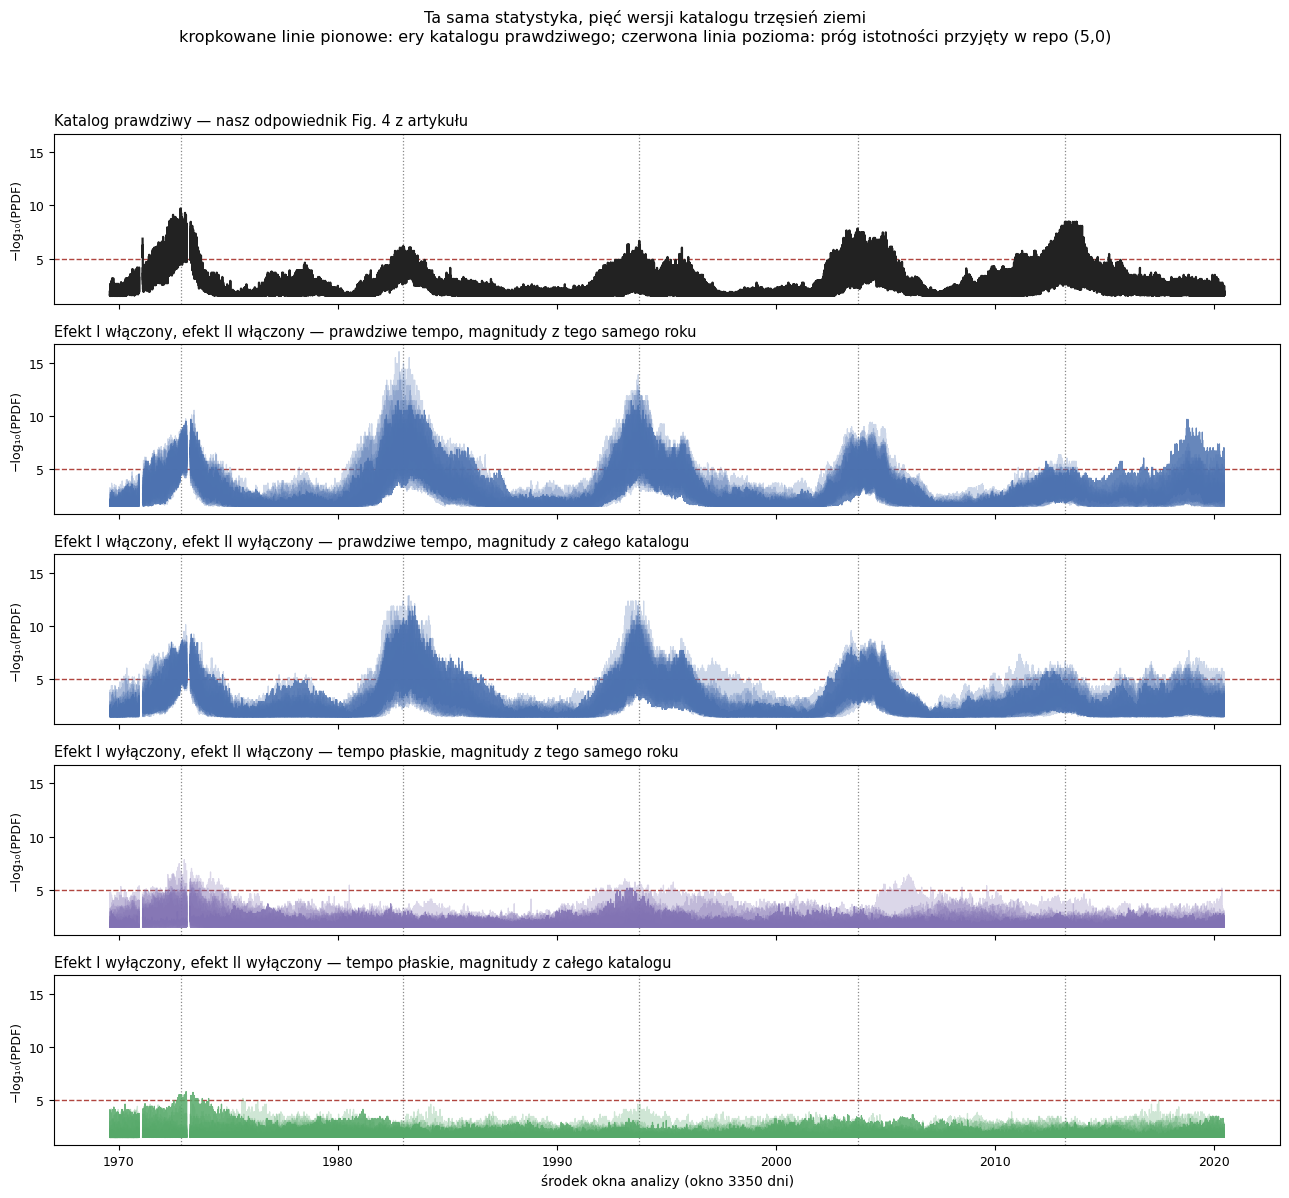

In [6]:
# JEZYK OPISOW NA RYSUNKACH. Prezentacja ma byc po angielsku (komentarz
# opiekuna [K2] z 03.09.2026), a rysunki w results/ sa dotad polskie - stad
# przelacznik zamiast dwoch wersji kodu. Zeby dostac drugi komplet plikow:
# zmien te stala i uruchom ponownie komorki 5, 6 i 7 (nazwy plikow maja
# przyrostek jezyka, wiec nic sie nie nadpisuje).
JEZYK = "pl"

# SUROWE KRZYWE, PELNA ROZDZIELCZOSC, BEZ WYGLADZANIA I BEZ AGREGATOW.
# Wersja posrednia tego notebooka rysowala mediane z pasmem 10-90% i maksimum
# punktowym, wygladzone oknem 180 dni. Zostala wycofana z jednego powodu:
# wszystkie wczesniejsze rysunki tego watku (fig4_porownanie_mosc.png,
# fig4_zaburzone_*.png) i sama Fig. 4 artykulu pokazuja SUROWE krzywe, wiec
# rysunek wygladzony nie daje sie z nimi zestawic. Pomiary, ktore przy tej
# okazji zrobiono, sa opisane w dzienniku (sekcja 2b) - w szczegolnosci to, ze
# sama mediana pokazywalaby ZERO er dla obu wersji z plaskim tempem, przy 0,80 i
# 0,08 podanych w podpisach.
import matplotlib.pyplot as plt

OPISY = {
    "pl": dict(
        os_y="−log₁₀(PPDF)",
        os_x="środek okna analizy (okno 3350 dni)",
        tytul=("Ta sama statystyka, pięć wersji katalogu trzęsień ziemi\n"
               "kropkowane linie pionowe: ery katalogu prawdziwego; "
               "czerwona linia pozioma: próg istotności przyjęty w repo (5,0)"),
        panele=["Katalog prawdziwy — nasz odpowiednik Fig. 4 z artykułu",
                "Efekt I włączony, efekt II włączony — prawdziwe tempo, magnitudy z tego samego roku",
                "Efekt I włączony, efekt II wyłączony — prawdziwe tempo, magnitudy z całego katalogu",
                "Efekt I wyłączony, efekt II włączony — tempo płaskie, magnitudy z tego samego roku",
                "Efekt I wyłączony, efekt II wyłączony — tempo płaskie, magnitudy z całego katalogu"],
        wiersze=["tempo prawdziwe\n(efekt I włączony)", "tempo płaskie\n(efekt I wyłączony)"],
        kolumny=["magnitudy z tego samego roku\n(efekt II włączony)",
                 "magnitudy z całego katalogu\n(efekt II wyłączony)"],
        tytul2=("Krzywe w stylu Fig. 4 dla pełnego planu 2×2\n"
                "katalogi surogatowe bez jakiegokolwiek związku z promieniowaniem kosmicznym; "
                f"{N_POKAZ} realizacji na wersję"),
        podpis_min="średnio {:.2f} er na realizację (20260903c, 50 realizacji)",
        # opisy rysunku 3 (komorka 7)
        t3_tytul=("Kontrola: katalog z wyłączonymi obydwoma trendami\n"
                  "reprezentatywna próbka {n} realizacji, dobrana po kwantylach "
                  "{kw} rozkładu maksimum krzywej ze wszystkich 50 realizacji"),
        t3_praw="Katalog prawdziwy — to samo, co widać na Fig. 4 artykułu",
        t3_kontrola=("Efekt I wyłączony, efekt II wyłączony — tempo płaskie, "
                     "magnitudy z całego katalogu"),
        t3_nota=("mediana maksimum po 50 realizacjach: {med:.2f}; "
                 "najwyższa z 50 realizacji: {mx:.2f} (ziarno {zmx});\n"
                 "próg 5,0 przekracza {ile} realizacji na 50, co odpowiada "
                 "0,08 ery na realizację podanym w 20260903c"),
    ),
    "en": dict(
        os_y="−log₁₀(PPDF)",
        os_x="centre of the analysis window (3350-day window)",
        tytul=("One statistic, five versions of the earthquake catalogue\n"
               "dotted vertical lines: eras of the real catalogue; "
               "red horizontal line: significance threshold used here (5.0)"),
        panele=["Real catalogue — our counterpart of Fig. 4 of the paper",
                "Effect I on, effect II on — true rate, magnitudes from the same year",
                "Effect I on, effect II off — true rate, magnitudes from the whole catalogue",
                "Effect I off, effect II on — flat rate, magnitudes from the same year",
                "Effect I off, effect II off — flat rate, magnitudes from the whole catalogue"],
        wiersze=["true event rate\n(effect I on)", "flat event rate\n(effect I off)"],
        kolumny=["magnitudes from the same year\n(effect II on)",
                 "magnitudes from the whole catalogue\n(effect II off)"],
        tytul2=("Fig. 4-style curves for the full 2×2 design\n"
                "surrogate catalogues with no cosmic-ray coupling by construction; "
                f"{N_POKAZ} realisations per version"),
        podpis_min="{:.2f} eras per realisation on average (20260903c, 50 realisations)",
        t3_tytul=("Control: catalogue with both trends switched off\n"
                  "representative sample of {n} realisations, taken at quantiles "
                  "{kw} of the curve-maximum distribution over all 50 realisations"),
        t3_praw="Real catalogue — the same as Fig. 4 of the paper shows",
        t3_kontrola=("Effect I off, effect II off — flat rate, magnitudes from the "
                     "whole catalogue"),
        t3_nota=("median of the maximum over 50 realisations: {med:.2f}; "
                 "highest of the 50: {mx:.2f} (seed {zmx});\n"
                 "{ile} of 50 realisations exceed the 5.0 threshold, which is the "
                 "0.08 eras per realisation quoted in 20260903c"),
    ),
}
OP = OPISY[JEZYK]
KOLORY = {"tempo_praw__mag_rok": "#4C72B0", "tempo_praw__mag_glob": "#4C72B0",
          "tempo_plaskie__mag_rok": "#8172B3", "tempo_plaskie__mag_glob": "#55A868"}
X = krzywe["srodek_okna"]


def ozdob(ax):
    ax.axhline(PROG_WYSOKOSCI, color="#B0453F", ls="--", lw=1.0, zorder=1)
    for d in daty_praw:
        ax.axvline(d + pd.Timedelta(days=P_DAYS / 2), color="#888888", ls=":", lw=0.9, zorder=1)


# RYSUNEK 1 - PIEC PANELI JEDEN POD DRUGIM, wspolna os czasu i WSPOLNA OS PIONOWA.
PANELE = ([(["prawdziwy__0"], "#222222", OP["panele"][0])]
          + [(KOL[w], KOLORY[w], t) for w, t in zip(WERSJE, OP["panele"][1:])])
fig, osie = plt.subplots(5, 1, figsize=(13, 12), sharex=True, sharey=True)
for ax, (kolumny_panelu, kolor, tytul) in zip(osie, PANELE):
    for i, k in enumerate(kolumny_panelu):
        ax.plot(X, krzywe[k], color=kolor,
                lw=1.6 if len(kolumny_panelu) == 1 else 0.9,
                alpha=1.0 if len(kolumny_panelu) == 1 else (0.85 if i == 0 else 0.28),
                zorder=3 if i == 0 else 2)
    ozdob(ax)
    ax.set_title(tytul, fontsize=10.5, loc="left", pad=6)
    ax.set_ylabel(OP["os_y"], fontsize=9)
    ax.tick_params(labelsize=9)
osie[-1].set_xlabel(OP["os_x"], fontsize=10)
fig.suptitle(OP["tytul"], fontsize=11.5, y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.962))
_p1 = f"{RESULTS_DIR}/credo_czynniki_fig4_panele_{STACJA}_{JEZYK}.png"
fig.savefig(_p1, dpi=150)
print(f"Zapisano {_p1}")


Zapisano ../results/credo_czynniki_fig4_2x2_mosc_pl.png


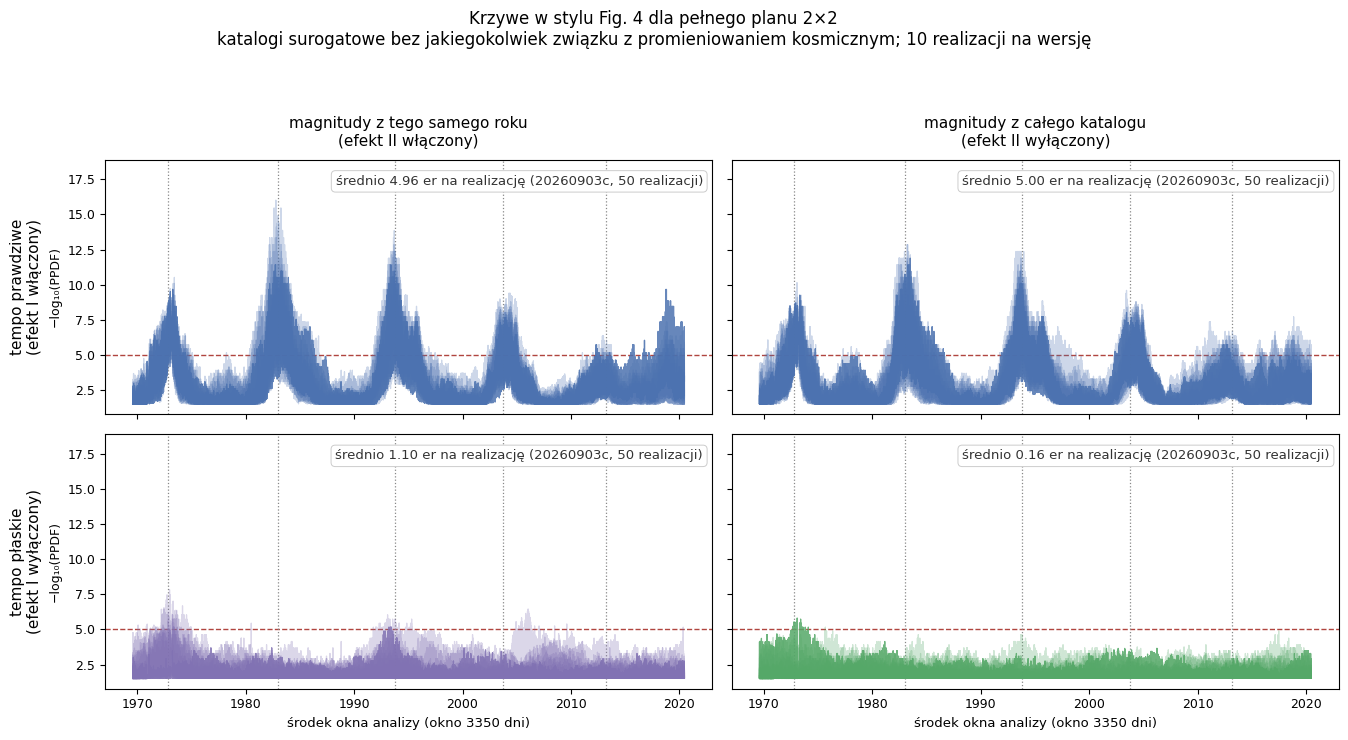

In [7]:
# RYSUNEK 2 - TEN SAM MATERIAL W UKLADZIE 2x2, zeby plan czynnikowy byl widac
# wprost: wiersze = przelacznik tempa, kolumny = przelacznik magnitud.
#
# BEZ KRZYWEJ KATALOGU PRAWDZIWEGO W TLE. Pierwsza wersja tego rysunku rysowala
# ja w kazdym panelu jako "odniesienie" i bylo to blednie zaprojektowane: w
# gornym wierszu ginela pod wiazka surogatow, a w dolnym byla najwyzsza krzywa w
# panelu i przebijala prog piec razy - przez co panel z wynikiem 0,08 wygladal
# tak, jakby produkowal ery. Odniesieniem, ktore w tym rysunku ma znaczenie, jest
# prog 5,0; katalog prawdziwy pokazuje rysunek 1, we wlasnym panelu.
fig, osie = plt.subplots(2, 2, figsize=(14, 7.5), sharex=True, sharey=True)
SIATKA_2X2 = [["tempo_praw__mag_rok", "tempo_praw__mag_glob"],
              ["tempo_plaskie__mag_rok", "tempo_plaskie__mag_glob"]]

for i in range(2):
    for j in range(2):
        w = SIATKA_2X2[i][j]
        ax = osie[i, j]
        for n, k in enumerate(KOL[w]):
            ax.plot(X, krzywe[k], color=KOLORY[w], lw=0.9,
                    alpha=0.85 if n == 0 else 0.28, zorder=3)
        ozdob(ax)
        ax.text(0.985, 0.94, OP["podpis_min"].format(float(ref_sr[w])),
                transform=ax.transAxes, ha="right", va="top", fontsize=9.5,
                color="#333333",
                bbox=dict(boxstyle="round,pad=0.32", fc="white", ec="#CCCCCC", lw=0.7))
        ax.tick_params(labelsize=9)
        if i == 0:
            ax.set_title(OP["kolumny"][j], fontsize=11, pad=10)
        if i == 1:
            ax.set_xlabel(OP["os_x"], fontsize=9.5)
        if j == 0:
            ax.set_ylabel(OP["os_y"], fontsize=9)
            ax.annotate(OP["wiersze"][i], xy=(-0.13, 0.5), xycoords="axes fraction",
                        ha="center", va="center", fontsize=11, rotation=90)

# Zapas nad najwyzsza krzywa, zeby ramka z liczba er nie kladla sie na dane.
_gora = float(np.nanmax(krzywe[[k for w in WERSJE for k in KOL[w]]].to_numpy()))
osie[0, 0].set_ylim(top=_gora * 1.18)

fig.suptitle(OP["tytul2"], fontsize=12)
fig.tight_layout(rect=(0.04, 0, 1, 0.93))
_p2 = f"{RESULTS_DIR}/credo_czynniki_fig4_2x2_{STACJA}_{JEZYK}.png"
fig.savefig(_p2, dpi=150, bbox_inches="tight")
print(f"Zapisano {_p2}")


Wersja tempo_plaskie__mag_glob, 50 realizacji: mediana maksimum 4.380, najwyzsza 6.041 (ziarno 20263919), powyzej progu 7/50.
Probka dobrana po kwantylach maksimum:
   q10: ziarno 20263924  maks 3.693  minimow 0
   q30: ziarno 20263905  maks 3.951  minimow 0
   q50: ziarno 20263950  maks 4.380  minimow 0
   q70: ziarno 20263934  maks 4.630  minimow 0
   q90: ziarno 20263915  maks 5.163  minimow 1
Liczymy 5 krzywych x 74322 punktow t0.
  1/5 krzywych; minelo 0.3 min, zostalo ~1.1 min
  2/5 krzywych; minelo 0.3 min, zostalo ~0.4 min
  3/5 krzywych; minelo 0.3 min, zostalo ~0.2 min
  4/5 krzywych; minelo 0.3 min, zostalo ~0.1 min
  5/5 krzywych; minelo 0.3 min, zostalo ~0.0 min
Czas: 0.3 min
Zapisano ../results/credo_czynniki_fig4_kontrola_mosc.csv
Zgodnosc maksimow z 20260903c: OK
Zapisano ../results/credo_czynniki_fig4_kontrola_mosc_pl.png


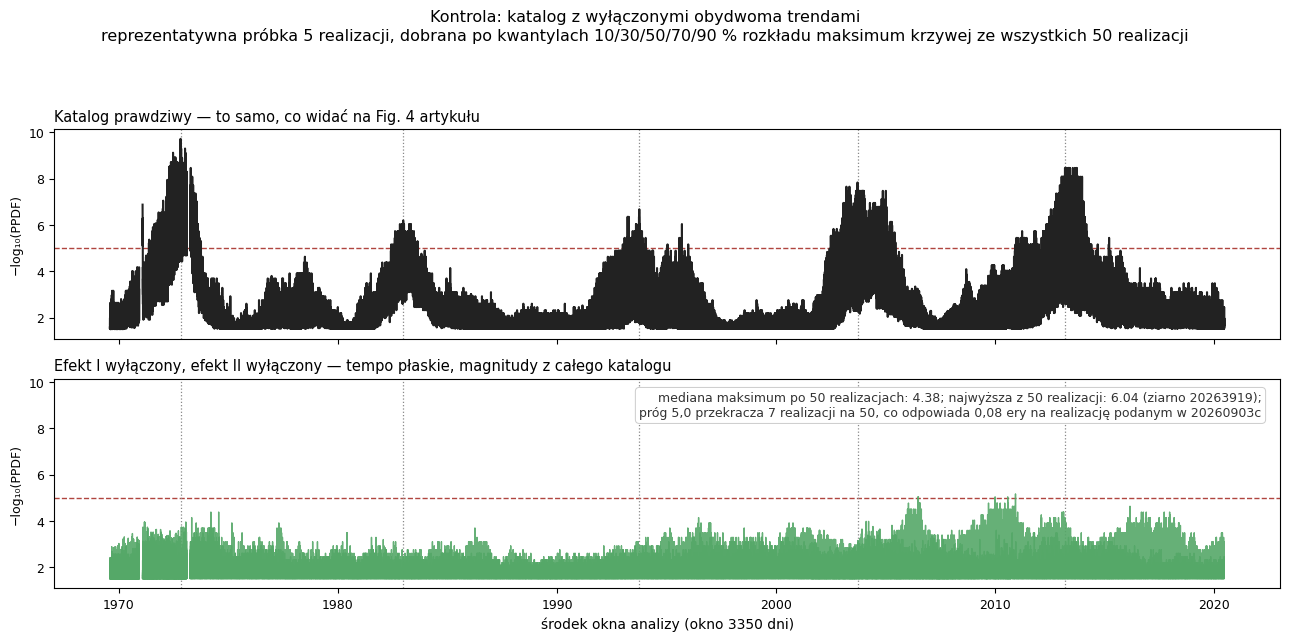

In [8]:
# RYSUNEK 3 - REPREZENTATYWNA PROBKA WERSJI "OBA PRZELACZNIKI WYLACZONE".
#
# PO CO OSOBNY RYSUNEK. Dziesiec realizacji na panelu z rysunkow 1 i 2 to
# pierwsze dziesiec ziaren, czyli probka arbitralna. Dla tej jednej wersji ma to
# znaczenie, bo jest to KONTROLA calej analizy i to na nia patrzy sie najuwazniej.
# Wsrod naszych dziesieciu jedna realizacja (ziarno 20263903, maks 5,109)
# przebija prog - co jest poprawne, ale wzrokowo dominuje panel i sugeruje, ze
# kontrola produkuje ery.
#
# REGULA DOBORU PROBKI, ZAPISANA PRZED LICZENIEM (zeby nie bylo doboru pod teze):
# bierzemy realizacje lezace na KWANTYLACH 10/30/50/70/90 % rozkladu maksimum
# krzywej po WSZYSTKICH 50 realizacjach z 20260903c. Probka jest wiec dobrana
# obiektywna statystyka policzona wczesniej, obejmuje caly zakres typowych
# zachowan, a nie jego kraniec, i da sie ja odtworzyc z samego pliku
# credo_czynniki_minima_mosc.csv.
#
# CZEGO TA PROBKA NIE UKRYWA - wypisane na rysunku: ile realizacji z 50 przebija
# prog i jak wysoko siega najwyzsza z nich. Bez tego probka typowych realizacji
# sugerowalaby, ze kontrola nie przebija progu NIGDY, a przebija w 4 przypadkach
# na 50 - i to wlasnie znaczy 0,08 ery na realizacje.
#
# KOSZT: 5 krzywych (zadna nie jest wsrod tych z komorki 3), okolo 18 sekund.
WERSJA_K = "tempo_plaskie__mag_glob"
KWANTYLE = [0.10, 0.30, 0.50, 0.70, 0.90]
SCIEZKA_K = f"{RESULTS_DIR}/credo_czynniki_fig4_kontrola_{STACJA}.csv"
SCIEZKA_K_KONF = f"{RESULTS_DIR}/credo_czynniki_fig4_kontrola_config_{STACJA}.json"

_g = (ref[ref.typ == WERSJA_K].sort_values("max_krzywej").reset_index(drop=True))
ZIARNA_K, _opis_k = [], []
for q in KWANTYLE:
    _i = (_g["max_krzywej"] - _g["max_krzywej"].quantile(q)).abs().idxmin()
    ZIARNA_K.append(int(_g.loc[_i, "ziarno"]))
    _opis_k.append((q, int(_g.loc[_i, "ziarno"]), float(_g.loc[_i, "max_krzywej"]),
                    int(_g.loc[_i, "n_minimow"])))
MED_K = float(_g["max_krzywej"].median())
MAX_K = float(_g["max_krzywej"].max())
ZMAX_K = int(_g.loc[_g["max_krzywej"].idxmax(), "ziarno"])
ILE_K = int((_g["n_minimow"] > 0).sum())

print(f"Wersja {WERSJA_K}, 50 realizacji: mediana maksimum {MED_K:.3f}, "
      f"najwyzsza {MAX_K:.3f} (ziarno {ZMAX_K}), powyzej progu {ILE_K}/50.")
print("Probka dobrana po kwantylach maksimum:")
for q, z, m, n in _opis_k:
    print(f"   q{int(q * 100):>2d}: ziarno {z}  maks {m:.3f}  minimow {n}")


def _konf_k():
    return dict(STACJA=STACJA, WERSJA=WERSJA_K, KWANTYLE=KWANTYLE,
                ZIARNA_K=ZIARNA_K, n_siatka=int(len(siatka)))


_wczytano_k = False
if os.path.exists(SCIEZKA_K) and os.path.exists(SCIEZKA_K_KONF):
    if json.load(open(SCIEZKA_K_KONF)) == json.loads(json.dumps(_konf_k())):
        kontrola = pd.read_csv(SCIEZKA_K, parse_dates=["srodek_okna"])
        _wczytano_k = True
        print(f"WCZYTANO {SCIEZKA_K} - nic nie liczono.")

if not _wczytano_k:
    print(f"Liczymy {len(ZIARNA_K)} krzywych x {len(siatka)} punktow t0.")
    _start = time.time()
    _sur = run_jobs_parallel(zadanie, [(WERSJA_K, z) for z in ZIARNA_K],
                             opis="krzywych", raport_co=1)
    print(f"Czas: {(time.time() - _start) / 60:.1f} min")
    _kol = {"srodek_okna": siatka.reset_index(drop=True) + pd.Timedelta(days=P_DAYS / 2)}
    for r_ in _sur.itertuples():
        _kol[r_.kolumna] = r_.krzywa
    kontrola = pd.DataFrame(_kol)
    kontrola.to_csv(SCIEZKA_K, index=False)
    json.dump(_konf_k(), open(SCIEZKA_K_KONF, "w"), indent=1)
    print(f"Zapisano {SCIEZKA_K}")

# KONTROLA: maksima policzonych krzywych musza zgadzac sie z 20260903c.
_zle_k = [(z, float(np.nanmax(kontrola[f"{WERSJA_K}__{z}"].to_numpy())),
           float(_g.loc[_g.ziarno == z, "max_krzywej"].iloc[0]))
          for z in ZIARNA_K
          if abs(float(np.nanmax(kontrola[f"{WERSJA_K}__{z}"].to_numpy()))
                 - float(_g.loc[_g.ziarno == z, "max_krzywej"].iloc[0])) > 1e-9]
print(f"Zgodnosc maksimow z 20260903c: {'OK' if not _zle_k else _zle_k}")

fig, osie = plt.subplots(2, 1, figsize=(13, 6.4), sharex=True, sharey=True)
osie[0].plot(kontrola["srodek_okna"], krzywe["prawdziwy__0"], color="#222222", lw=1.5, zorder=3)
osie[0].set_title(OP["t3_praw"], fontsize=10.5, loc="left", pad=6)
for n, z in enumerate(ZIARNA_K):
    osie[1].plot(kontrola["srodek_okna"], kontrola[f"{WERSJA_K}__{z}"],
                 color=KOLORY[WERSJA_K], lw=1.0, alpha=0.9, zorder=3)
osie[1].set_title(OP["t3_kontrola"], fontsize=10.5, loc="left", pad=6)
for ax in osie:
    ozdob(ax)
    ax.set_ylabel(OP["os_y"], fontsize=9)
    ax.tick_params(labelsize=9)
osie[1].set_xlabel(OP["os_x"], fontsize=10)
osie[1].text(0.985, 0.94, OP["t3_nota"].format(med=MED_K, mx=MAX_K, zmx=ZMAX_K, ile=ILE_K),
             transform=osie[1].transAxes, ha="right", va="top", fontsize=9,
             color="#333333",
             bbox=dict(boxstyle="round,pad=0.32", fc="white", ec="#CCCCCC", lw=0.7))
fig.suptitle(OP["t3_tytul"].format(n=len(ZIARNA_K),
                                   kw="/".join(f"{int(q * 100)}" for q in KWANTYLE) + " %"),
             fontsize=11.5, y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.94))
_p3 = f"{RESULTS_DIR}/credo_czynniki_fig4_kontrola_{STACJA}_{JEZYK}.png"
fig.savefig(_p3, dpi=150)
print(f"Zapisano {_p3}")
